In [40]:
# ==============================
# Step 1: Import Required Libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [41]:
# ==============================
# Step 2: Load Dataset
# ==============================

file_path = "crude-oil-price.csv"

df = pd.read_csv(file_path)

First Look at the Data

In [42]:
# Display first 5 rows
df.head()

,date,price,percentChange,change
0,1983-03-01 00:00:00+00:00,29.27,NaN,NaN
1,1983-04-01 00:00:00+00:00,30.63,4.646,1.36
2,1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
3,1983-06-01 00:00:00+00:00,31.38,3.736,1.13
4,1983-07-01 00:00:00+00:00,32.00,1.976,0.62


In [43]:
# Display last 5 rows
df.tail()

,date,price,percentChange,change
515,2026-02-01 00:00:00+00:00,67.0200,2.776,1.8100
516,2026-03-01 00:00:00+00:00,101.3800,51.268,34.3600
517,2026-04-01 00:00:00+00:00,105.0700,3.640,3.6900
518,2026-05-01 00:00:00+00:00,87.3600,-16.855,-17.7100
519,2026-06-01 00:00:00+00:00,95.3522,9.149,7.9922


In [44]:
# Display random 5 rows
df.sample(5, random_state=42)

,date,price,percentChange,change
275,2006-02-01 00:00:00+00:00,61.41,-9.585,-6.51
93,1990-12-01 00:00:00+00:00,28.44,-1.421,-0.41
6,1983-09-01 00:00:00+00:00,30.36,-3.894,-1.23
167,1997-02-01 00:00:00+00:00,20.30,-15.942,-3.85
90,1990-09-01 00:00:00+00:00,39.51,44.619,12.19


In [45]:
# Number of rows and columns (Dataset Shape)
df.shape

(520, 4)

In [46]:
# Display column names
df.columns

Index(['date', 'price', 'percentChange', 'change'], dtype='object')

In [47]:
## Dataset Info
# General information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           520 non-null    object 
 1   price          520 non-null    float64
 2   percentChange  519 non-null    float64
 3   change         519 non-null    float64
dtypes: float64(3), object(1)
memory usage: 16.4+ KB


In [48]:
# Statistical summary of numerical columns
df.describe()

,price,percentChange,change
count,520.000000,519.000000,519.000000
mean,47.331953,0.771850,0.127326
std,28.959532,10.605003,5.225282
min,10.420000,-54.245000,-32.830000
25%,20.590000,-5.159000,-1.740000
50%,37.215000,0.929000,0.270000
75%,69.907500,6.295000,2.475000
max,140.000000,88.376000,34.360000


In [49]:
# Check missing values
df.isnull().sum()

date             0
price            0
percentChange    1
change           1
dtype: int64

In [50]:
# Check duplicate rows
df.duplicated().sum()

0

In [51]:
# Rename columns for better readability
df = df.rename(columns={
    "percentChange": "percent_change"
})

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            520 non-null    object 
 1   price           520 non-null    float64
 2   percent_change  519 non-null    float64
 3   change          519 non-null    float64
dtypes: float64(3), object(1)
memory usage: 16.4+ KB


Result

In [53]:
#Dataset contains 520 monthly records.
#Date range starts from 1983.
#There are 4 columns.
#Only percent_change and change have 1 missing value.
#The date column needs conversion to datetime.

In [54]:
# ==============================
# Convert Date Column
# ==============================

df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   date            520 non-null    datetime64[ns, UTC]
 1   price           520 non-null    float64            
 2   percent_change  519 non-null    float64            
 3   change          519 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(3)
memory usage: 16.4 KB


In [55]:
# ==============================
# Sort By Date
# ==============================

df = df.sort_values("date")

df = df.reset_index(drop=True)

In [56]:
# ==============================
# Set Date As Index
# ==============================

df = df.set_index("date")

In [57]:
df.head()

,price,percent_change,change
date,,,
1983-03-01 00:00:00+00:00,29.27,NaN,NaN
1983-04-01 00:00:00+00:00,30.63,4.646,1.36
1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
1983-06-01 00:00:00+00:00,31.38,3.736,1.13
1983-07-01 00:00:00+00:00,32.00,1.976,0.62


In [60]:
# ==============================
# Extract Year
# Extract Month
# ==============================

df["month"] = df.index.month
df["year"] = df.index.year

In [61]:
# ==============================
# Month Name
# ==============================

df["month_name"] = df.index.month_name()

In [62]:
# ==============================
# Quarter
# ==============================

df["quarter"] = df.index.quarter

In [63]:
# ==============================
# Decade
# ==============================

df["decade"] = (df["year"] // 10) * 10

In [64]:
df["decade"]

date
1983-03-01 00:00:00+00:00    1980
1983-04-01 00:00:00+00:00    1980
1983-05-01 00:00:00+00:00    1980
1983-06-01 00:00:00+00:00    1980
1983-07-01 00:00:00+00:00    1980
                             ... 
2026-02-01 00:00:00+00:00    2020
2026-03-01 00:00:00+00:00    2020
2026-04-01 00:00:00+00:00    2020
2026-05-01 00:00:00+00:00    2020
2026-06-01 00:00:00+00:00    2020
Name: decade, Length: 520, dtype: int32

In [ ]:
# ==============================
# Check Dataset Time Range
# Determine the first and last date
# available in the dataset
# ==============================

print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 1983-03-01 00:00:00+00:00
End Date: 2026-06-01 00:00:00+00:00


In [ ]:
# ==============================
# Count Number of Records Per Year
# Used to verify data completeness
# ==============================

records_per_year = df.groupby("year").size()

records_per_year.head()

year
1983    10
1984    12
1985    12
1986    12
1987    12
dtype: int64

In [ ]:
# ==============================
# Count Records Per Decade
# Useful for long-term analysis
# ==============================

records_per_decade = df.groupby("decade").size()

records_per_decade

decade
1980     82
1990    120
2000    120
2010    120
2020     78
dtype: int64

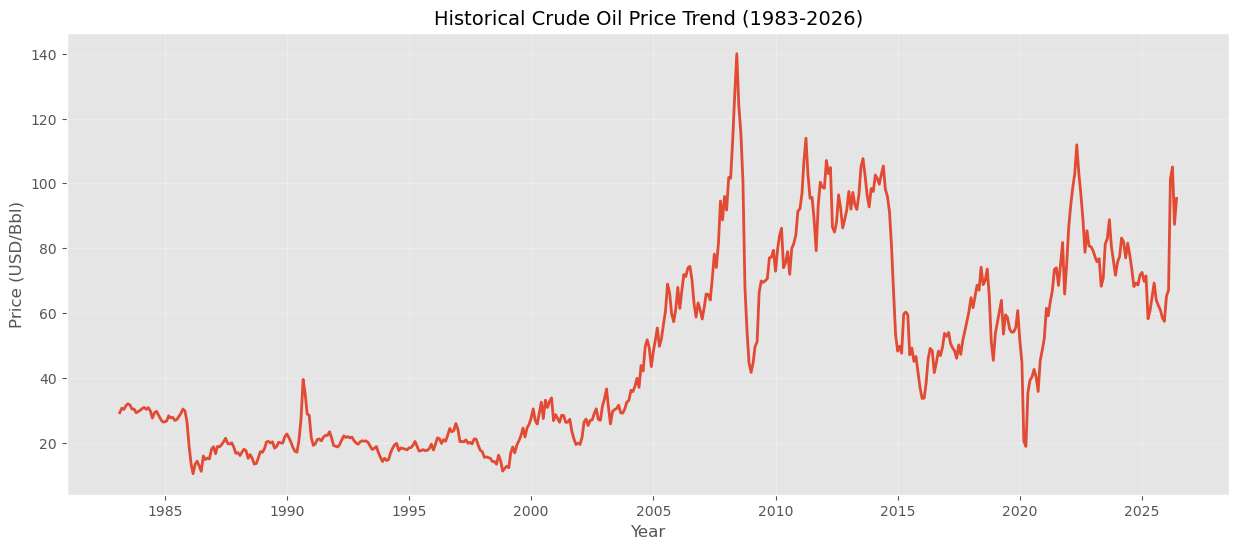

In [68]:
# ==============================
# Plot Historical Oil Prices
# Visualize long-term oil price trend
# from 1983 to 2026
# ==============================

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["price"],
    linewidth=2
)

plt.title(
    "Historical Crude Oil Price Trend (1983-2026)",
    fontsize=14
)

plt.xlabel("Year")
plt.ylabel("Price (USD/Bbl)")

plt.grid(alpha=0.3)

plt.show()

# Initial Business Insights

This dataset spans more than four decades of crude oil price history, covering major economic events, geopolitical tensions, financial crises, and supply-demand shocks.

Key observations:

- The dataset contains 520 monthly records.
- The analysis period covers approximately 43 years.
- Historical coverage extends from March 1983 to June 2026.
- The data captures several major oil market events, including:
  - The 1986 Oil Price Collapse
  - The Gulf War (1990–1991)
  - The 2008 Global Financial Crisis
  - The COVID-19 Oil Market Shock (2020)
  - The Russia–Ukraine War (2022)

To facilitate long-term analysis, the market will be segmented into five decades:

1. 1980s
2. 1990s
3. 2000s
4. 2010s
5. 2020s

This segmentation will allow us to compare average prices, volatility, market trends, and crisis impacts across different periods.

# EDA

## Questions for Further Analysis

The following questions will guide the exploratory data analysis (EDA) phase of this project.

### Q1. Which decade had the highest average oil price?

This analysis will help identify the most expensive period in the history of the crude oil market and reveal long-term pricing trends.

---

### Q2. Which decade experienced the highest volatility?

By measuring price fluctuations across decades, we can identify periods of market instability and uncertainty.

---

### Q3. In which year did crude oil reach its all-time highest price?

This analysis will help locate major market peaks and connect them to historical economic or geopolitical events.

---

### Q4. In which year did crude oil experience its largest decline?

Understanding major downturns can reveal the impact of financial crises, supply shocks, and demand collapses.

---

### Q5. Has the long-term trend of crude oil prices been upward?

A trend analysis will determine whether crude oil prices have generally increased over the last four decades despite short-term fluctuations.

---

### Expected Outcome

The answers to these questions will provide insights into:

- Long-term market behavior
- Economic and geopolitical impacts on oil prices
- Historical periods of growth and decline
- Market volatility across decades
- Structural changes in the global energy market

In [ ]:
# Exploratory Data Analysis (EDA)

# The purpose of this phase is to understand the distribution, behavior, and characteristics of crude oil prices before performing advanced analysis.

# The analysis focuses on:

# - Price distribution
# - Outlier detection
# - Market volatility
# - Price changes over time
# - Statistical characteristics of the dataset

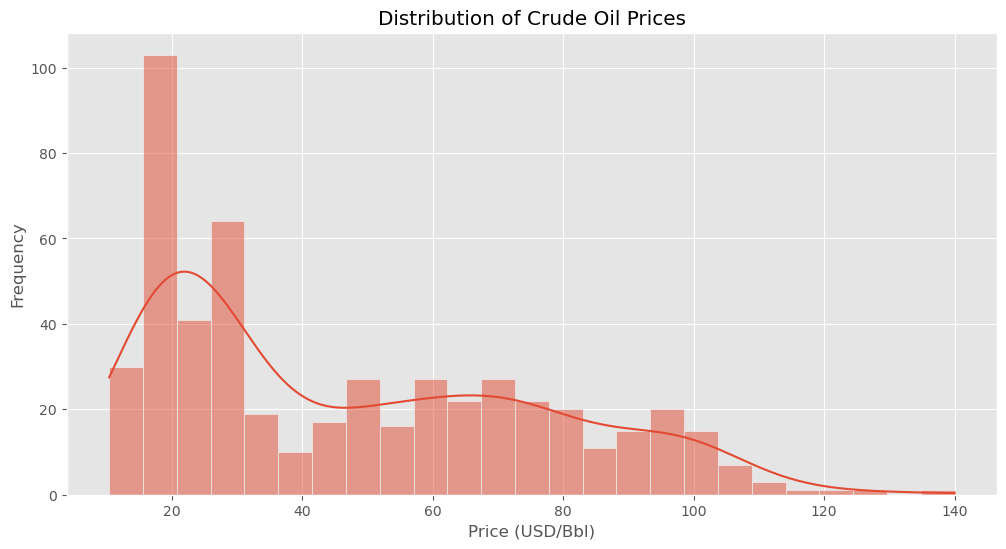

In [69]:
# ==============================
# Distribution of Oil Prices
# Visualize the distribution of
# crude oil prices
# ==============================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="price",
    bins=25,
    kde=True
)

plt.title("Distribution of Crude Oil Prices")
plt.xlabel("Price (USD/Bbl)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Initial Observation

# The distribution of crude oil prices is not perfectly normal.

# The presence of multiple peaks may indicate different market regimes, reflecting periods of low, medium, and high oil prices throughout history.

# Further investigation is required to identify potential outliers and structural market shifts.

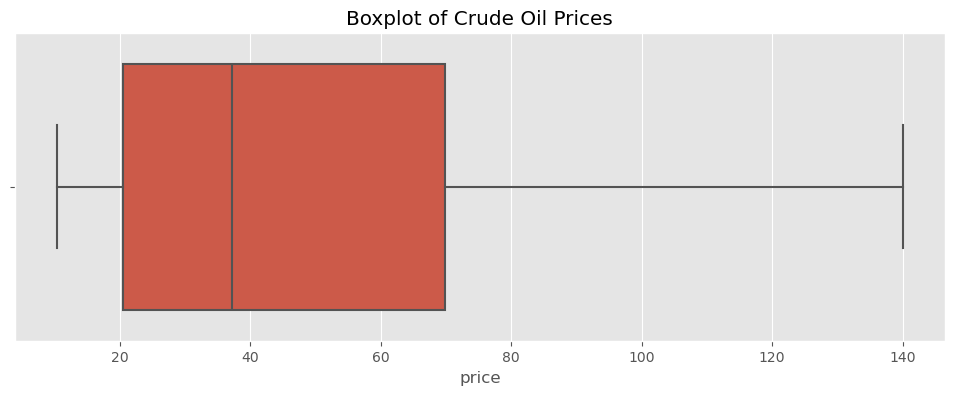

In [70]:
# ==============================
# Detect Potential Outliers
# ==============================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of Crude Oil Prices")

plt.show()

In [ ]:
## Outlier Analysis

# The boxplot helps identify extreme price levels.

# Potential outliers are expected during major market events such as:

# - The 2008 Oil Price Boom
# - The COVID-19 Market Shock
# - The Russia–Ukraine Conflict

# These observations may represent genuine market events rather than data quality issues.

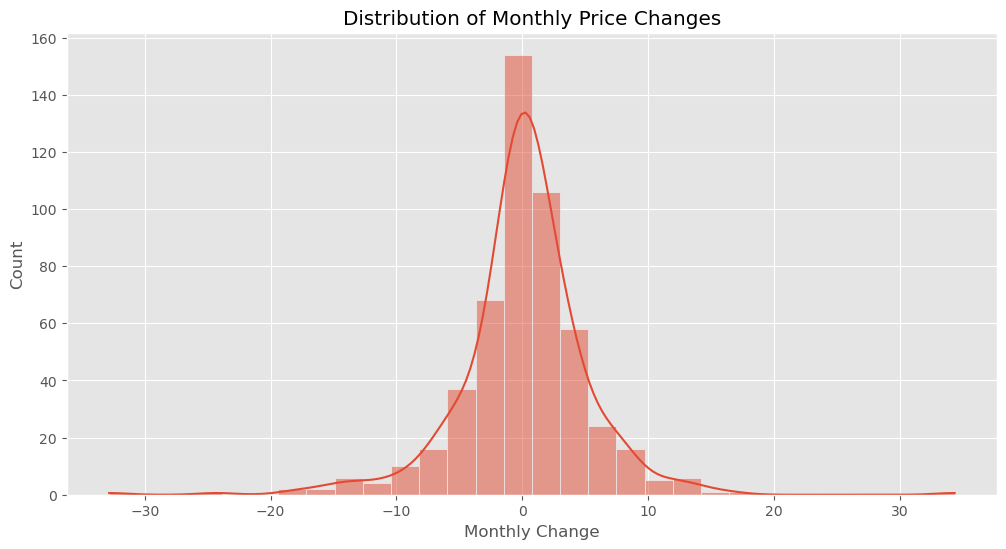

In [71]:
# ==============================
# Distribution of Monthly Price Changes
# ==============================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="change",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Price Changes")
plt.xlabel("Monthly Change")

plt.show()

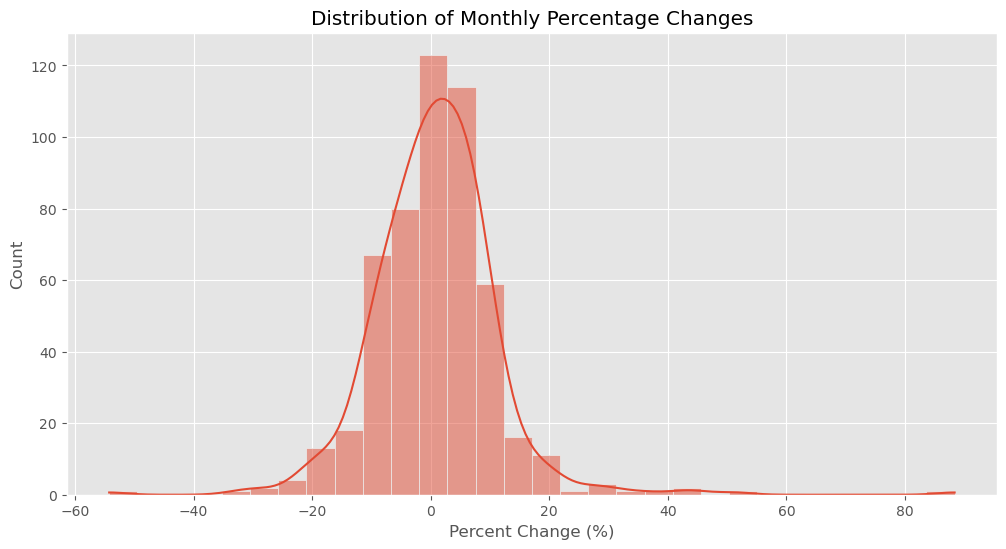

In [73]:
# ==============================
# Distribution of Monthly Percentage Changes
# ==============================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="percent_change",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Percentage Changes")
plt.xlabel("Percent Change (%)")

plt.show()

In [74]:
# ==============================
# Measure Distribution Skewness
# ==============================

price_skewness = df["price"].skew()

print(f"Price Skewness: {price_skewness:.2f}")

Price Skewness: 0.64


In [75]:
# ==============================
# Measure Distribution Kurtosis
# ==============================

price_kurtosis = df["price"].kurtosis()

print(f"Price Kurtosis: {price_kurtosis:.2f}")

Price Kurtosis: -0.75


In [77]:
# ==============================
# Correlation Between Variables
# ==============================

corr_matrix = df[
    ["price", "change", "percent_change"]
].corr()

corr_matrix

,price,change,percent_change
price,1.000000,0.102809,0.073318
change,0.102809,1.000000,0.835632
percent_change,0.073318,0.835632,1.000000


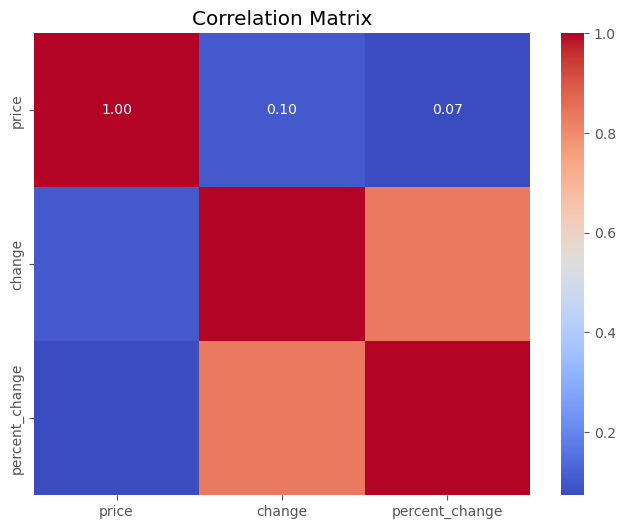

In [78]:
# ==============================
# Correlation Heatmap
# ==============================

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Conclusion – Understanding Market Behavior

The exploratory analysis reveals that crude oil prices are not concentrated around a single price level.

Instead, the market appears to operate across multiple pricing environments, suggesting that different periods of history were governed by different market conditions.

Most monthly price movements remain relatively moderate, while large changes occur infrequently. This indicates that significant market disruptions are the exception rather than the norm.

The distribution of prices also suggests that extreme price levels are uncommon and occur only during exceptional periods.

At this stage, the analysis provides an understanding of how the market behaves statistically. However, it does not yet explain how prices evolve over time.

The next phase shifts the focus from distribution and variability to trend analysis, aiming to determine whether long-term market cycles exist.

## Hypothesis 1

Oil prices move through long-term market cycles rather than random fluctuations.

## Hypothesis 2

Major geopolitical events create larger price shocks than ordinary economic conditions.

## Hypothesis 3

Market volatility increases significantly during crisis periods.

# Time Series Analysis

The objective of this phase is to identify long-term trends, market cycles, and volatility patterns in crude oil prices.

This section focuses on:

- Long-term market trend
- Moving averages
- Volatility analysis
- Decade comparison
- Market cycles
- Historical market shocks

In [79]:
# ==============================
# Create Moving Averages
# ==============================

df["MA_12"] = df["price"].rolling(window=12).mean()

df["MA_24"] = df["price"].rolling(window=24).mean()

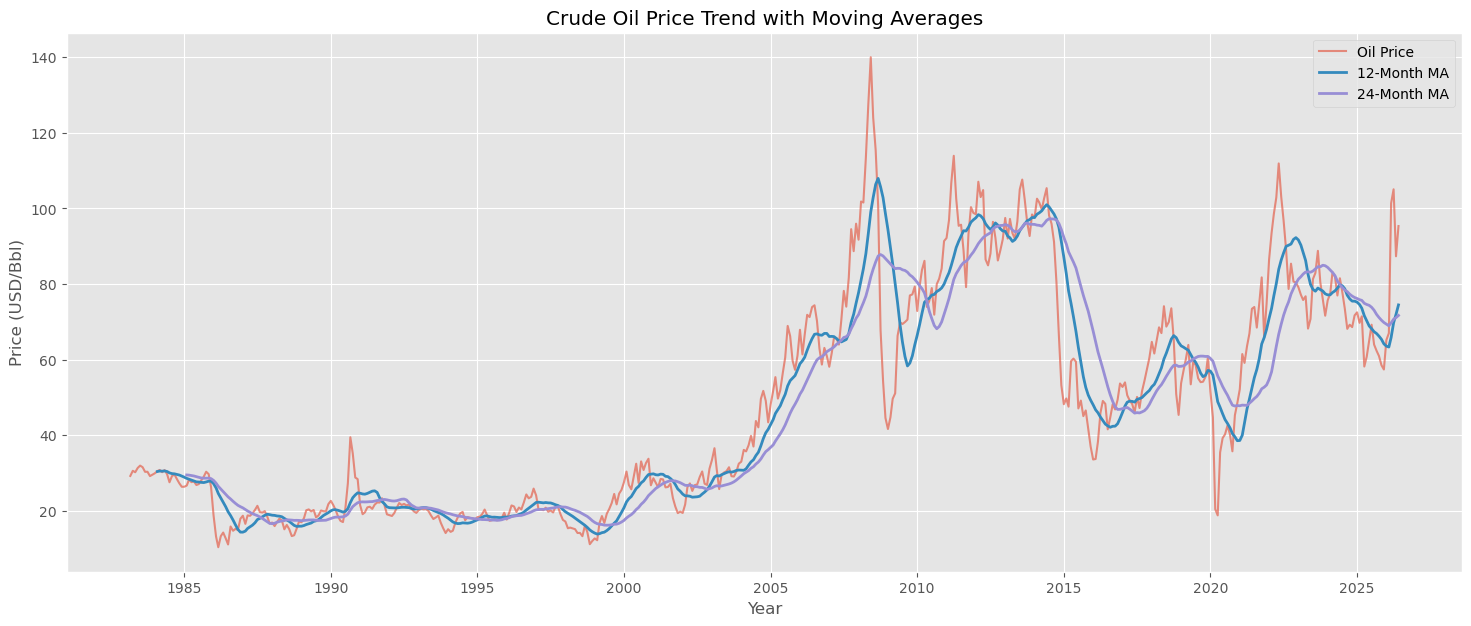

In [80]:
# ==============================
# Plot Price with Moving Averages
# ==============================

plt.figure(figsize=(18,7))

plt.plot(
    df.index,
    df["price"],
    label="Oil Price",
    alpha=0.6
)

plt.plot(
    df.index,
    df["MA_12"],
    label="12-Month MA",
    linewidth=2
)

plt.plot(
    df.index,
    df["MA_24"],
    label="24-Month MA",
    linewidth=2
)

plt.title("Crude Oil Price Trend with Moving Averages")

plt.xlabel("Year")
plt.ylabel("Price (USD/Bbl)")

plt.legend()

plt.show()

In [ ]:
## Trend Analysis

# The moving averages smooth short-term fluctuations and reveal the underlying market trend.

# Key questions:

# - Is the long-term trend upward?
# - How many major market cycles can be identified?
# - How long do bullish and bearish periods last?

# The moving average curves will help distinguish temporary shocks from structural trends.

In [81]:
# ==============================
# Rolling Volatility
# 12-Month Rolling Standard Deviation
# ==============================

df["volatility_12"] = (
    df["price"]
    .rolling(12)
    .std()
)

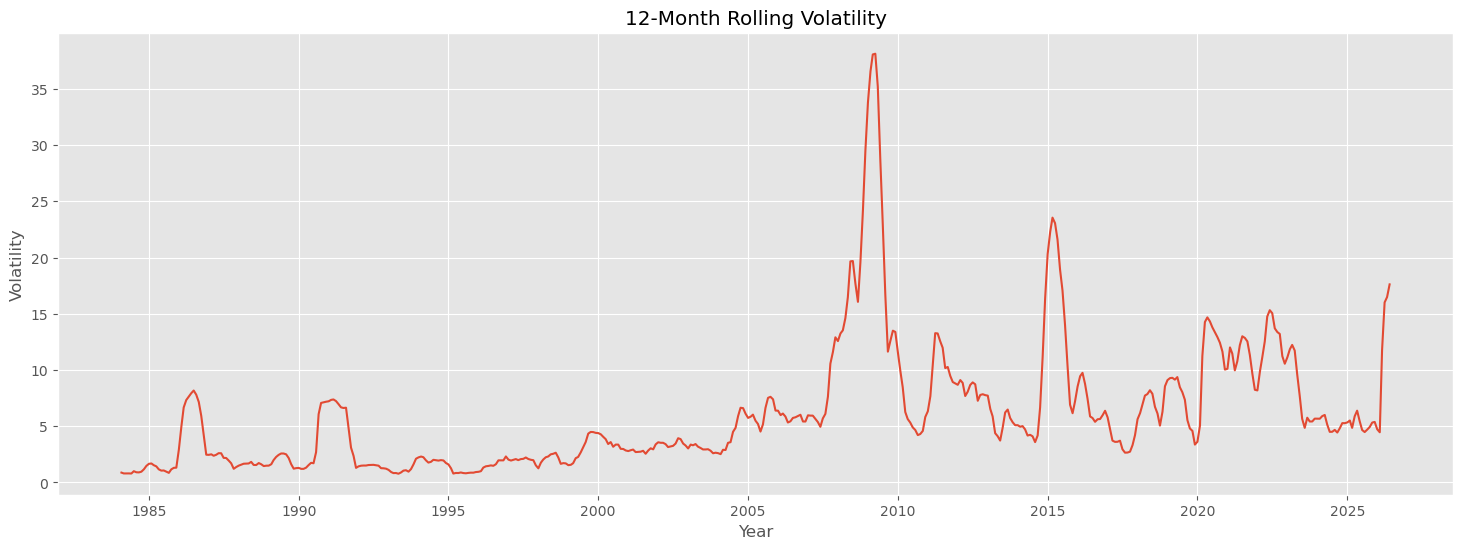

In [82]:
# ==============================
# Visualize Market Volatility
# ==============================

plt.figure(figsize=(18,6))

plt.plot(
    df.index,
    df["volatility_12"]
)

plt.title("12-Month Rolling Volatility")

plt.xlabel("Year")
plt.ylabel("Volatility")

plt.show()

In [83]:
## Volatility Analysis

# Periods of high volatility indicate uncertainty and instability in the oil market.

# Expected volatility spikes:

# - 1986 Oil Price Collapse
# - Gulf War (1990)
# - Financial Crisis (2008)
# - COVID-19 Shock (2020)
# - Russia–Ukraine Conflict (2022)

#Volatility analysis helps identify crisis periods more clearly than price levels alone.

In [84]:
# ==============================
# Average Price by Decade
# ==============================

decade_price = (
    df.groupby("decade")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(decade_price)

decade
2010    72.727665
2020    70.699176
2000    51.567750
1980    22.170976
1990    19.705083
Name: price, dtype: float64


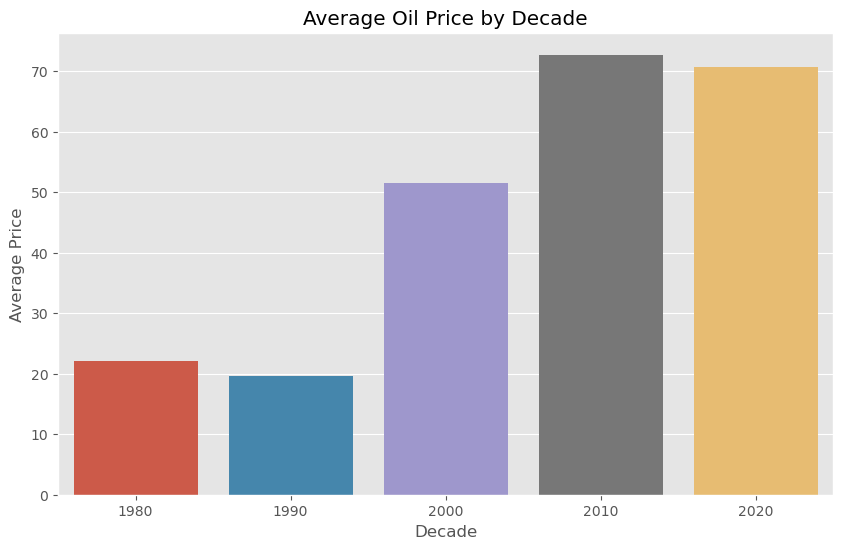

In [85]:
# ==============================
# Average Price by Decade
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    x=decade_price.index,
    y=decade_price.values
)

plt.title("Average Oil Price by Decade")

plt.xlabel("Decade")
plt.ylabel("Average Price")

plt.show()

In [86]:
# ==============================
# Volatility by Decade
# ==============================

decade_volatility = (
    df.groupby("decade")["price"]
      .std()
      .sort_values(ascending=False)
)

print(decade_volatility)

decade
2000    26.092415
2010    21.893184
2020    18.545946
1980     6.326177
1990     3.935554
Name: price, dtype: float64


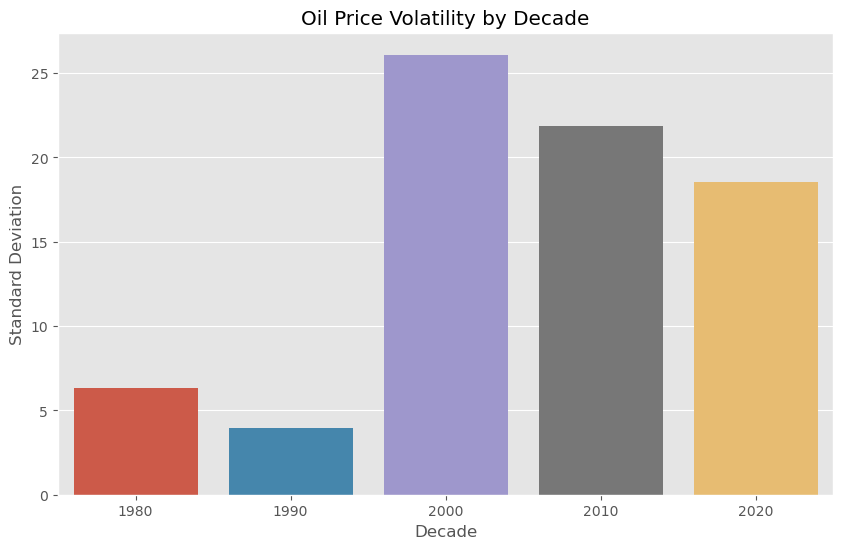

In [87]:
# ==============================
# Price Volatility by Decade
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    x=decade_volatility.index,
    y=decade_volatility.values
)

plt.title("Oil Price Volatility by Decade")

plt.xlabel("Decade")
plt.ylabel("Standard Deviation")

plt.show()

In [88]:
# ==============================
# Top 10 Highest Oil Prices
# ==============================

top_prices = (
    df.nlargest(
        10,
        "price"
    )
)

top_prices[
    ["price", "year"]
]

,price,year
date,,
2008-06-01 00:00:00+00:00,140.00,2008
2008-05-01 00:00:00+00:00,127.35,2008
2008-07-01 00:00:00+00:00,124.08,2008
2008-08-01 00:00:00+00:00,115.46,2008
2011-04-01 00:00:00+00:00,113.93,2011
2008-04-01 00:00:00+00:00,113.46,2008
2022-05-01 00:00:00+00:00,111.91,2022
2013-08-01 00:00:00+00:00,107.65,2013
2012-02-01 00:00:00+00:00,107.07,2012


In [89]:
# ==============================
# Top 10 Largest Monthly Declines
# ==============================

largest_crashes = (
    df.nsmallest(
        10,
        "percent_change"
    )
)

largest_crashes[
    ["price",
     "percent_change",
     "year"]
]

,price,percent_change,year
date,,,
2020-03-01 00:00:00+00:00,20.48,-54.245,2020
2008-10-01 00:00:00+00:00,67.81,-32.621,2008
1986-02-01 00:00:00+00:00,13.26,-29.580,1986
1986-01-01 00:00:00+00:00,18.83,-28.403,1986
1991-01-01 00:00:00+00:00,21.54,-24.262,1991
1998-11-01 00:00:00+00:00,11.22,-22.191,1998
2018-11-01 00:00:00+00:00,50.93,-22.018,2018
1986-03-01 00:00:00+00:00,10.42,-21.418,1986
2015-07-01 00:00:00+00:00,47.12,-20.767,2015


In [90]:
# ==============================
# Annual Average Price
# ==============================

yearly_price = (
    df.groupby("year")["price"]
      .mean()
      .reset_index()
)

In [91]:
# ==============================
# Annual Price Change
# ==============================

yearly_price["annual_change"] = (
    yearly_price["price"]
    .pct_change()
    * 100
)

In [92]:
# ==============================
# Bull vs Bear Years
# ==============================

bull_years = yearly_price[
    yearly_price["annual_change"] > 0
]

bear_years = yearly_price[
    yearly_price["annual_change"] < 0
]

print("Bull Years:", len(bull_years))
print("Bear Years:", len(bear_years))

Bull Years: 22
Bear Years: 21


In [95]:
yearly_price.tail(15)

,year,price,annual_change
29,2012,94.051667,-3.041185
30,2013,97.607500,3.780723
31,2014,91.227500,-6.536383
32,2015,49.307500,-45.951056
33,2016,44.468333,-9.814261
34,2017,51.855000,16.611072
35,2018,64.589742,24.558368
36,2019,57.182742,-11.467765
37,2020,38.595833,-32.504402
38,2021,68.069167,76.364029


# Identifying Long-Term Market Cycles

After examining crude oil prices over more than four decades, a clear pattern begins to emerge.

The market does not behave as a series of isolated price fluctuations. Instead, it moves through distinct long-term cycles characterized by periods of growth, correction, stability, and recovery.

The moving average analysis reveals that major market shifts often develop gradually over several years rather than appearing as short-term reactions. While monthly price movements can be highly volatile, the broader market follows identifiable long-term trends.

The decade comparison further highlights that different periods of history were shaped by different market environments. Some decades were defined by relatively stable prices, while others experienced sustained periods of elevated price levels and increased uncertainty.

Another important observation is that volatility is not constant. Periods of market instability tend to cluster together, suggesting that uncertainty builds around specific turning points rather than being evenly distributed over time.

At this stage, we can conclude that crude oil prices are driven by structural market forces and long-term cycles rather than random movements alone.

However, one critical question remains unanswered:

**What caused these turning points and market transitions?**

To answer this question, the next phase investigates the historical events that coincided with major market shifts and explores how geopolitical conflicts, economic crises, and global disruptions shaped the evolution of the oil market.

In [ ]:
# 5.Historical Events and Market Turning Points

# After identifying long-term market cycles, the next step is to understand what caused the major turning points in crude oil prices.

# This phase investigates the relationship between historical events and oil market behavior.

# The analysis focuses on:

# - Market disruptions
# - Economic crises
# - Geopolitical conflicts
# - Recovery periods
# - Structural shifts in oil prices

In [96]:
# ==============================
# Major Historical Events
# Used to compare oil price behavior
# against significant global events
# ==============================

events = {
    "1986 Oil Collapse": "1986-01-01",
    "Gulf War": "1990-08-01",
    "Asian Financial Crisis": "1997-07-01",
    "Global Financial Crisis": "2008-09-01",
    "COVID-19 Pandemic": "2020-03-01",
    "Russia-Ukraine War": "2022-02-01"
}

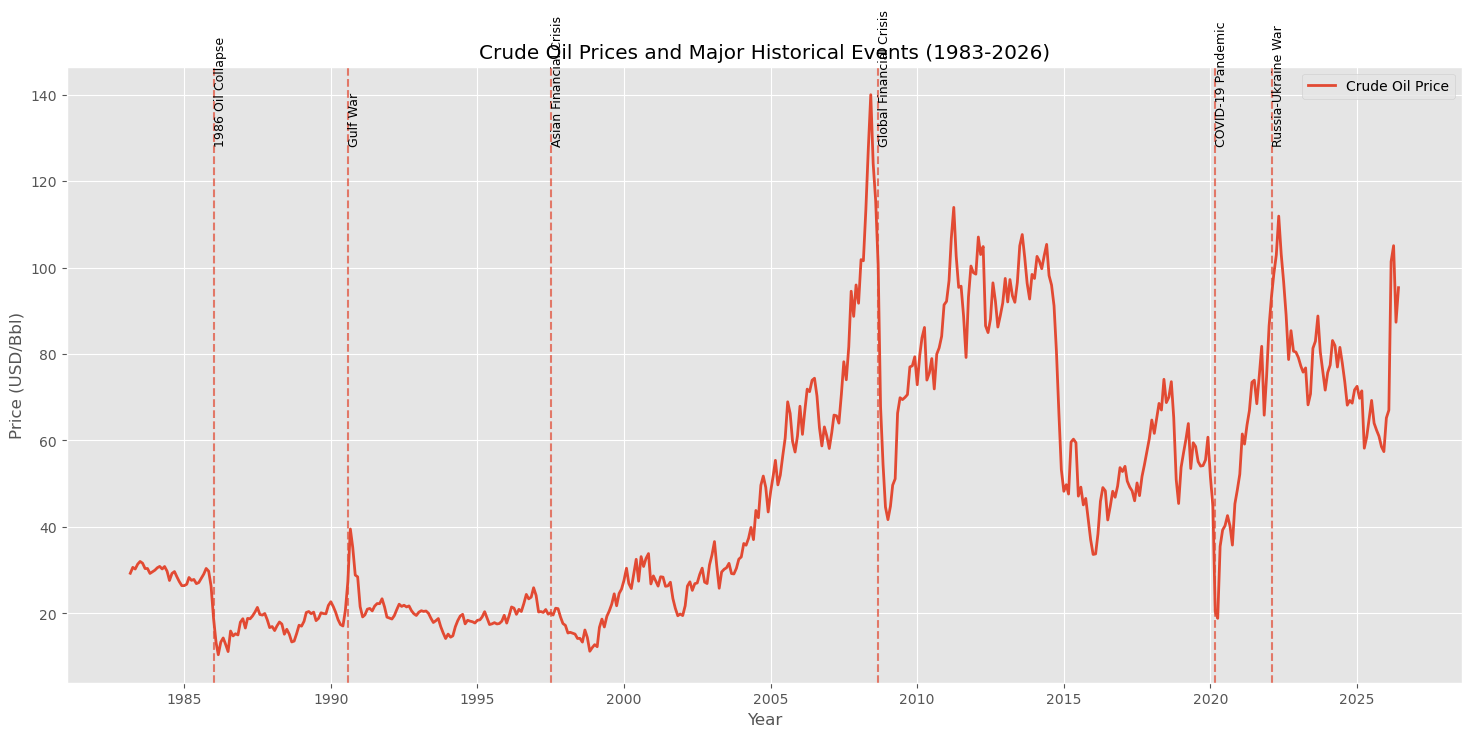

In [97]:
# ==============================
# Oil Prices and Major Events
# ==============================

plt.figure(figsize=(18,8))

plt.plot(
    df.index,
    df["price"],
    linewidth=2,
    label="Crude Oil Price"
)

for event, event_date in events.items():

    plt.axvline(
        pd.to_datetime(event_date),
        linestyle="--",
        alpha=0.7
    )

    plt.text(
        pd.to_datetime(event_date),
        df["price"].max() * 0.92,
        event,
        rotation=90,
        fontsize=9
    )

plt.title(
    "Crude Oil Prices and Major Historical Events (1983-2026)"
)

plt.xlabel("Year")
plt.ylabel("Price (USD/Bbl)")

plt.legend()

plt.show()

In [98]:
# ==============================
# Historical Event Summary
# ==============================

event_summary = pd.DataFrame({

    "Event": [
        "1986 Oil Collapse",
        "Gulf War",
        "Asian Financial Crisis",
        "Global Financial Crisis",
        "COVID-19 Pandemic",
        "Russia-Ukraine War"
    ],

    "Market Impact": [
        "Major price collapse",
        "Supply uncertainty",
        "Demand slowdown",
        "Demand destruction",
        "Historic demand shock",
        "Energy supply disruption"
    ]
})

event_summary

,Event,Market Impact
0,1986 Oil Collapse,Major price collapse
1,Gulf War,Supply uncertainty
2,Asian Financial Crisis,Demand slowdown
3,Global Financial Crisis,Demand destruction
4,COVID-19 Pandemic,Historic demand shock
5,Russia-Ukraine War,Energy supply disruption


In [99]:
# ==============================
# Largest Monthly Declines
# ==============================

largest_crashes = df.nsmallest(
    10,
    "percent_change"
)[
    ["price",
     "percent_change",
     "year"]
]

largest_crashes

,price,percent_change,year
date,,,
2020-03-01 00:00:00+00:00,20.48,-54.245,2020
2008-10-01 00:00:00+00:00,67.81,-32.621,2008
1986-02-01 00:00:00+00:00,13.26,-29.580,1986
1986-01-01 00:00:00+00:00,18.83,-28.403,1986
1991-01-01 00:00:00+00:00,21.54,-24.262,1991
1998-11-01 00:00:00+00:00,11.22,-22.191,1998
2018-11-01 00:00:00+00:00,50.93,-22.018,2018
1986-03-01 00:00:00+00:00,10.42,-21.418,1986
2015-07-01 00:00:00+00:00,47.12,-20.767,2015


In [100]:
# ==============================
# Largest Monthly Increases
# ==============================

largest_rallies = df.nlargest(
    10,
    "percent_change"
)[
    ["price",
     "percent_change",
     "year"]
]

largest_rallies

,price,percent_change,year
date,,,
2020-05-01 00:00:00+00:00,35.49,88.376,2020
2026-03-01 00:00:00+00:00,101.38,51.268,2026
1990-09-01 00:00:00+00:00,39.51,44.619,1990
1986-08-01 00:00:00+00:00,15.90,42.601,1986
1999-03-01 00:00:00+00:00,16.76,36.593,1999
1990-08-01 00:00:00+00:00,27.32,32.044,1990
2009-05-01 00:00:00+00:00,66.31,29.714,2009
1986-04-01 00:00:00+00:00,13.34,28.023,1986
2020-11-01 00:00:00+00:00,45.34,26.683,2020


In [101]:
# ==============================
# Selected Crisis Years
# ==============================

crisis_years = yearly_price[
    yearly_price["year"].isin(
        [1986, 1990, 2008, 2020, 2022]
    )
]

crisis_years

,year,price,annual_change
3,1986,14.413333,-48.289883
7,1990,24.795833,26.681710
25,2008,98.583333,31.542370
37,2020,38.595833,-32.504402
39,2022,92.289167,35.581455


# Conclusion – Understanding Market Turning Points

The previous phase demonstrated that crude oil prices move through long-term market cycles. This phase helps explain why those cycles occur.

A review of major historical events shows that the most significant market turning points were rarely driven by ordinary market activity. Instead, they emerged during periods of exceptional disruption.

Economic crises, geopolitical conflicts, and sudden shifts in global demand repeatedly acted as catalysts for major price movements. These events did not simply create temporary fluctuations; in many cases, they altered the direction of the market for several years.

An important pattern also emerges when comparing market declines and recoveries. Severe disruptions are often followed by equally powerful rebounds, suggesting that the oil market has historically demonstrated a strong capacity for recovery after periods of extreme stress.

At the same time, not all events produced the same type of response. Some triggered rapid price increases through supply concerns, while others caused sharp declines by reducing global demand. The market's reaction depended not only on the event itself, but also on the underlying economic conditions at the time.

The evidence suggests that understanding oil prices requires more than analyzing historical trends. Major turning points can only be fully understood when market behavior is examined alongside the broader economic and geopolitical context.

Having identified both the long-term cycles and the events that shaped them, the final phase will focus on extracting executive-level insights and translating the analysis into practical conclusions.

In [ ]:
# 6. Executive Insights

# After analyzing more than four decades of crude oil price data, the final phase focuses on translating analytical findings into business insights.

# The goal is not to describe historical events, but to understand what they reveal about the behavior of the oil market.

# This section summarizes the most important lessons from the analysis and highlights the broader implications of long-term market trends, volatility, and external disruptions.

In [102]:
# ==============================
# Price Regime Classification
# ==============================

def classify_price(price):

    if price < 30:
        return "Low Price"

    elif price < 80:
        return "Medium Price"

    else:
        return "High Price"


df["price_regime"] = df["price"].apply(classify_price)

regime_counts = (
    df["price_regime"]
    .value_counts()
)

print(regime_counts)

price_regime
Low Price       222
Medium Price    212
High Price       86
Name: count, dtype: int64


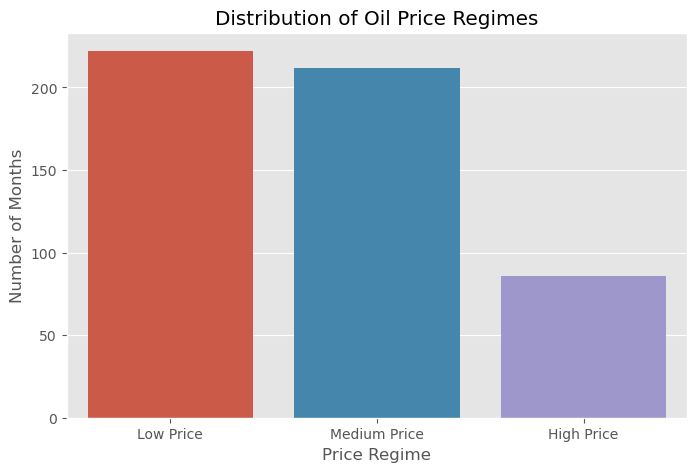

In [103]:
# ==============================
# Oil Price Regimes
# ==============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="price_regime",
    order=["Low Price",
           "Medium Price",
           "High Price"]
)

plt.title("Distribution of Oil Price Regimes")

plt.xlabel("Price Regime")
plt.ylabel("Number of Months")

plt.show()

In [104]:
# ==============================
# Monthly Average Price
# ==============================

monthly_avg = (
    df.groupby("month")["price"]
      .mean()
      .reset_index()
)

monthly_avg

,month,price
0,1,45.613488
1,2,46.548140
2,3,47.550989
3,4,48.680000
4,5,48.351364
5,6,49.622780
6,7,48.420000
7,8,48.138319
8,9,47.855563
9,10,46.724186


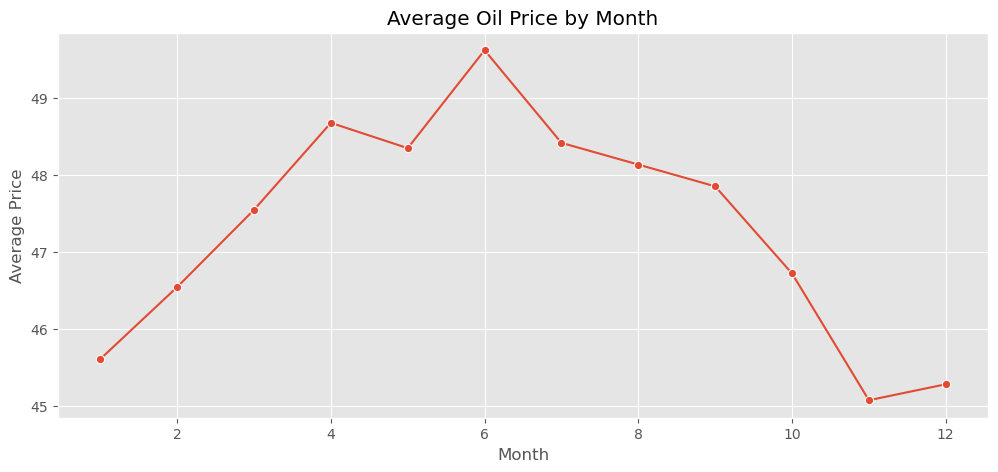

In [105]:
# ==============================
# Monthly Average Price
# ==============================

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_avg,
    x="month",
    y="price",
    marker="o"
)

plt.title(
    "Average Oil Price by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

In [106]:
# ==============================
# Executive Summary Metrics
# ==============================

summary = {

    "Dataset Period":
        "1983 - 2026",

    "Total Observations":
        len(df),

    "Highest Price":
        df["price"].max(),

    "Lowest Price":
        df["price"].min(),

    "Average Price":
        round(df["price"].mean(), 2),

    "Bull Years":
        len(bull_years),

    "Bear Years":
        len(bear_years)

}

summary

{'Dataset Period': '1983 - 2026',
 'Total Observations': 520,
 'Highest Price': 140.0,
 'Lowest Price': 10.42,
 'Average Price': 47.33,
 'Bull Years': 22,
 'Bear Years': 21}

# Executive Summary

This project analyzed 520 monthly crude oil price observations covering the period from March 1983 to June 2026.

The objective was to understand how crude oil prices evolved over time, identify long-term market patterns, and investigate the factors behind major market turning points.

---

## Key Findings

### The Oil Market Operates in Distinct Cycles

The analysis shows that crude oil prices do not follow a continuous upward or downward path.

Instead, the market moves through recurring cycles of expansion, correction, recovery, and stabilization.

Several major market regimes were identified throughout the study period, highlighting the cyclical nature of global energy markets.

---

### Long-Term Trends Matter More Than Short-Term Noise

Although monthly price movements can be highly volatile, long-term trends reveal a much clearer picture of market behavior.

Moving average analysis demonstrated that major market shifts often develop over several years rather than through isolated monthly fluctuations.

---

### The Most Volatile Decade Was the 2000s

The 2000s experienced the highest level of price volatility in the dataset.

This period included both the strongest bull market and one of the largest market collapses, emphasizing the importance of global economic conditions in shaping oil prices.

---

### Extraordinary Events Drive Extraordinary Market Movements

The largest market disruptions were consistently associated with major external events.

The analysis identified several critical turning points, including:

- The 1986 Oil Price Collapse
- The Gulf War
- The 2008 Global Financial Crisis
- The COVID-19 Pandemic
- The Russia–Ukraine Energy Crisis

These events significantly altered market direction and volatility patterns.

---

### Recovery Is a Fundamental Characteristic of the Oil Market

Despite experiencing severe declines, the oil market repeatedly demonstrated the ability to recover.

The strongest rebounds often followed periods of extreme market stress, indicating that long-term market dynamics extend beyond short-term disruptions.

---

### Most of the Study Period Was Spent in Low and Medium Price Environments

Price regime analysis revealed:

| Regime | Number of Months |
|---------|---------|
| Low Price (< 30 USD/Bbl) | 222 |
| Medium Price (30–80 USD/Bbl) | 212 |
| High Price (> 80 USD/Bbl) | 86 |

This suggests that exceptionally high oil prices represent relatively rare market conditions rather than the historical norm.

---

## Final Conclusion

The crude oil market is shaped by the interaction of economic cycles, geopolitical developments, and structural shifts in global energy demand.

While short-term price movements are often unpredictable, long-term analysis reveals recurring patterns that help explain how the market responds to periods of growth, uncertainty, and disruption.

Understanding these patterns provides valuable context for interpreting historical market behavior and evaluating future energy market developments.